# Unsupervised Learning: Trade & Ahead

## Problem Statement

### Context

The stock market has consistently proven to be a good place to invest in and save for the future. There are a lot of compelling reasons to invest in stocks. It can help in fighting inflation, create wealth, and also provides some tax benefits. Good steady returns on investments over a long period of time can also grow a lot more than seems possible. Also, thanks to the power of compound interest, the earlier one starts investing, the larger the corpus one can have for retirement. Overall, investing in stocks can help meet life's financial aspirations.

It is important to maintain a diversified portfolio when investing in stocks in order to maximise earnings under any market condition. Having a diversified portfolio tends to yield higher returns and face lower risk by tempering potential losses when the market is down. It is often easy to get lost in a sea of financial metrics to analyze while determining the worth of a stock, and doing the same for a multitude of stocks to identify the right picks for an individual can be a tedious task. By doing a cluster analysis, one can identify stocks that exhibit similar characteristics and ones which exhibit minimum correlation. This will help investors better analyze stocks across different market segments and help protect against risks that could make the portfolio vulnerable to losses.


### Objective

Trade&Ahead is a financial consultancy firm who provide their customers with personalized investment strategies. They have hired you as a Data Scientist and provided you with data comprising stock price and some financial indicators for a few companies listed under the New York Stock Exchange. They have assigned you the tasks of analyzing the data, grouping the stocks based on the attributes provided, and sharing insights about the characteristics of each group.

### Data Dictionary

- Ticker Symbol: An abbreviation used to uniquely identify publicly traded shares of a particular stock on a particular stock market
- Company: Name of the company
- GICS Sector: The specific economic sector assigned to a company by the Global Industry Classification Standard (GICS) that best defines its business operations
- GICS Sub Industry: The specific sub-industry group assigned to a company by the Global Industry Classification Standard (GICS) that best defines its business operations
- Current Price: Current stock price in dollars
- Price Change: Percentage change in the stock price in 13 weeks
- Volatility: Standard deviation of the stock price over the past 13 weeks
- ROE: A measure of financial performance calculated by dividing net income by shareholders' equity (shareholders' equity is equal to a company's assets minus its debt)
- Cash Ratio: The ratio of a  company's total reserves of cash and cash equivalents to its total current liabilities
- Net Cash Flow: The difference between a company's cash inflows and outflows (in dollars)
- Net Income: Revenues minus expenses, interest, and taxes (in dollars)
- Earnings Per Share: Company's net profit divided by the number of common shares it has outstanding (in dollars)
- Estimated Shares Outstanding: Company's stock currently held by all its shareholders
- P/E Ratio: Ratio of the company's current stock price to the earnings per share
- P/B Ratio: Ratio of the company's stock price per share by its book value per share (book value of a company is the net difference between that company's total assets and total liabilities)

## Importing necessary libraries and data

In [1]:
# Installing the libraries with the specified version.
# uncomment and run the following line if Google Colab is being used
# !pip install scikit-learn==1.6.1 seaborn==0.13.2 matplotlib==3.10.0 numpy==2.0.2 pandas==2.2.2 yellowbrick==1.5 -q --user

In [2]:
# Installing the libraries with the specified version.
# uncomment and run the following lines if Jupyter Notebook is being used
# !pip install scikit-learn==1.2.2 seaborn==0.13.1 matplotlib==3.7.1 numpy==1.25.2 pandas==1.5.2 yellowbrick==1.5 -q --user
# !pip install --upgrade -q jinja2 --no-warn-script-location

**Note**: *After running the above cell, kindly restart the notebook kernel and run all cells sequentially from the start again.*

In [3]:
# Importing libraries
# Libraries for data handling
import pandas as pd
import numpy as np
# Libraries for visualization
import matplotlib.pyplot as plt
import seaborn as sns
# Preprocessing and clustering
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
# Hierarchical clustering and cophenetic correlation
from scipy.cluster.hierarchy import dendrogram, linkage, cophenet
from scipy.spatial.distance import pdist
# K selection visualizers
from yellowbrick.cluster import KElbowVisualizer, SilhouetteVisualizer



## Data Overview

- Observations
- Sanity checks

In [4]:
# Loading dataset 
Trade_df = pd.read_csv('stock_data.csv')
Trade_df.head()

,Ticker Symbol,Security,GICS Sector,GICS Sub Industry,Current Price,Price Change,Volatility,ROE,Cash Ratio,Net Cash Flow,Net Income,Earnings Per Share,Estimated Shares Outstanding,P/E Ratio,P/B Ratio
0,AAL,American Airlines Group,Industrials,Airlines,42.349998,9.999995,1.687151,135,51,-604000000,7610000000,11.39,6.681299e+08,3.718174,-8.784219
1,ABBV,AbbVie,Health Care,Pharmaceuticals,59.240002,8.339433,2.197887,130,77,51000000,5144000000,3.15,1.633016e+09,18.806350,-8.750068
2,ABT,Abbott Laboratories,Health Care,Health Care Equipment,44.910000,11.301121,1.273646,21,67,938000000,4423000000,2.94,1.504422e+09,15.275510,-0.394171
3,ADBE,Adobe Systems Inc,Information Technology,Application Software,93.940002,13.977195,1.357679,9,180,-240840000,629551000,1.26,4.996437e+08,74.555557,4.199651
4,ADI,"Analog Devices, Inc.",Information Technology,Semiconductors,55.320000,-1.827858,1.701169,14,272,315120000,696878000,0.31,2.247994e+09,178.451613,1.059810


In [5]:
Trade_df.shape

(340, 15)

* The datasets consists of 340 rows and 15 columns.

In [6]:
# Checks datatypes
Trade_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 340 entries, 0 to 339
Data columns (total 15 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Ticker Symbol                 340 non-null    object 
 1   Security                      340 non-null    object 
 2   GICS Sector                   340 non-null    object 
 3   GICS Sub Industry             340 non-null    object 
 4   Current Price                 340 non-null    float64
 5   Price Change                  340 non-null    float64
 6   Volatility                    340 non-null    float64
 7   ROE                           340 non-null    int64  
 8   Cash Ratio                    340 non-null    int64  
 9   Net Cash Flow                 340 non-null    int64  
 10  Net Income                    340 non-null    int64  
 11  Earnings Per Share            340 non-null    float64
 12  Estimated Shares Outstanding  340 non-null    float64
 13  P/E R

#### Observation
The dataset consists of 4 categorical columns and 11 numerical columns.

- Four columns are of object type: Ticker Symbol, Security, GICS Sector, and GICS Sub Industry.
- Seven columns are of float64 type: Current Price, Price Change, Volatility, Earnings Per Share, Estimated Shares Outstanding, P/E Ratio, and P/B Ratio.
- Four columns are of int64 type: ROE, Cash Ratio, Net Cash Flow, and Net Income.

In [7]:
# Statistical Summary 
Trade_df.describe().T

,count,mean,std,min,25%,50%,75%,max
Current Price,340.0,8.086234e+01,9.805509e+01,4.500000e+00,3.855500e+01,5.970500e+01,9.288000e+01,1.274950e+03
Price Change,340.0,4.078194e+00,1.200634e+01,-4.712969e+01,-9.394838e-01,4.819505e+00,1.069549e+01,5.505168e+01
Volatility,340.0,1.525976e+00,5.917984e-01,7.331632e-01,1.134878e+00,1.385593e+00,1.695549e+00,4.580042e+00
ROE,340.0,3.959706e+01,9.654754e+01,1.000000e+00,9.750000e+00,1.500000e+01,2.700000e+01,9.170000e+02
Cash Ratio,340.0,7.002353e+01,9.042133e+01,0.000000e+00,1.800000e+01,4.700000e+01,9.900000e+01,9.580000e+02
Net Cash Flow,340.0,5.553762e+07,1.946365e+09,-1.120800e+10,-1.939065e+08,2.098000e+06,1.698108e+08,2.076400e+10
Net Income,340.0,1.494385e+09,3.940150e+09,-2.352800e+10,3.523012e+08,7.073360e+08,1.899000e+09,2.444200e+10
Earnings Per Share,340.0,2.776662e+00,6.587779e+00,-6.120000e+01,1.557500e+00,2.895000e+00,4.620000e+00,5.009000e+01
Estimated Shares Outstanding,340.0,5.770283e+08,8.458496e+08,2.767216e+07,1.588482e+08,3.096751e+08,5.731175e+08,6.159292e+09
P/E Ratio,340.0,3.261256e+01,4.434873e+01,2.935451e+00,1.504465e+01,2.081988e+01,3.176476e+01,5.280391e+02


#### Observation

- Current Price has a mean of 80.86 and a median of 59.71, with values ranging from 4.50 to 1,274.95, indicating considerable variation in stock prices.
- Price Change has a mean of 4.08%, with values ranging from -47.13% to 55.05%, showing that some stocks experienced both significant decreases and increases.
- Volatility has a mean of 1.53 and ranges from 0.73 to 4.58, indicating differences in the level of price fluctuations among the stocks.
- ROE and Cash Ratio show substantial variation, with maximum values of 917 and 958 respectively, suggesting the presence of potential outliers.
- Net Cash Flow and Net Income have large standard deviations compared to their means, indicating considerable variation in financial performance across companies.
- P/E Ratio has a mean of 32.61 and a median of 20.82, while its maximum value of 528.04 suggests the presence of potential outliers.
- P/B Ratio has a mean of -1.72 and ranges from -76.12 to 129.06, indicating substantial variation among companies.

In [8]:
# Checking Missing values
Trade_df.isnull().sum()

Ticker Symbol                   0
Security                        0
GICS Sector                     0
GICS Sub Industry               0
Current Price                   0
Price Change                    0
Volatility                      0
ROE                             0
Cash Ratio                      0
Net Cash Flow                   0
Net Income                      0
Earnings Per Share              0
Estimated Shares Outstanding    0
P/E Ratio                       0
P/B Ratio                       0
dtype: int64

* There  no missing values in the dataset.

In [9]:
# Checking for duplicates 
Trade_df.duplicated().sum()

0

* There are no duplicate records in the dataset.

## Exploratory Data Analysis (EDA)

- EDA is an important part of any project involving data.
- It is important to investigate and understand the data better before building a model with it.
- A few questions have been mentioned below which will help you approach the analysis in the right manner and generate insights from the data.
- A thorough analysis of the data, in addition to the questions mentioned below, should be done.

**Questions**:

1. What does the distribution of stock prices look like?
2. The stocks of which economic sector have seen the maximum price increase on average?
3. How are the different variables correlated with each other?
4. Cash ratio provides a measure of a company's ability to cover its short-term obligations using only cash and cash equivalents. How does the average cash ratio vary across economic sectors?
5. P/E ratios can help determine the relative value of a company's shares as they signify the amount of money an investor is willing to invest in a single share of a company per dollar of its earnings. How does the P/E ratio vary, on average, across economic sectors?

### Univariant Analysis

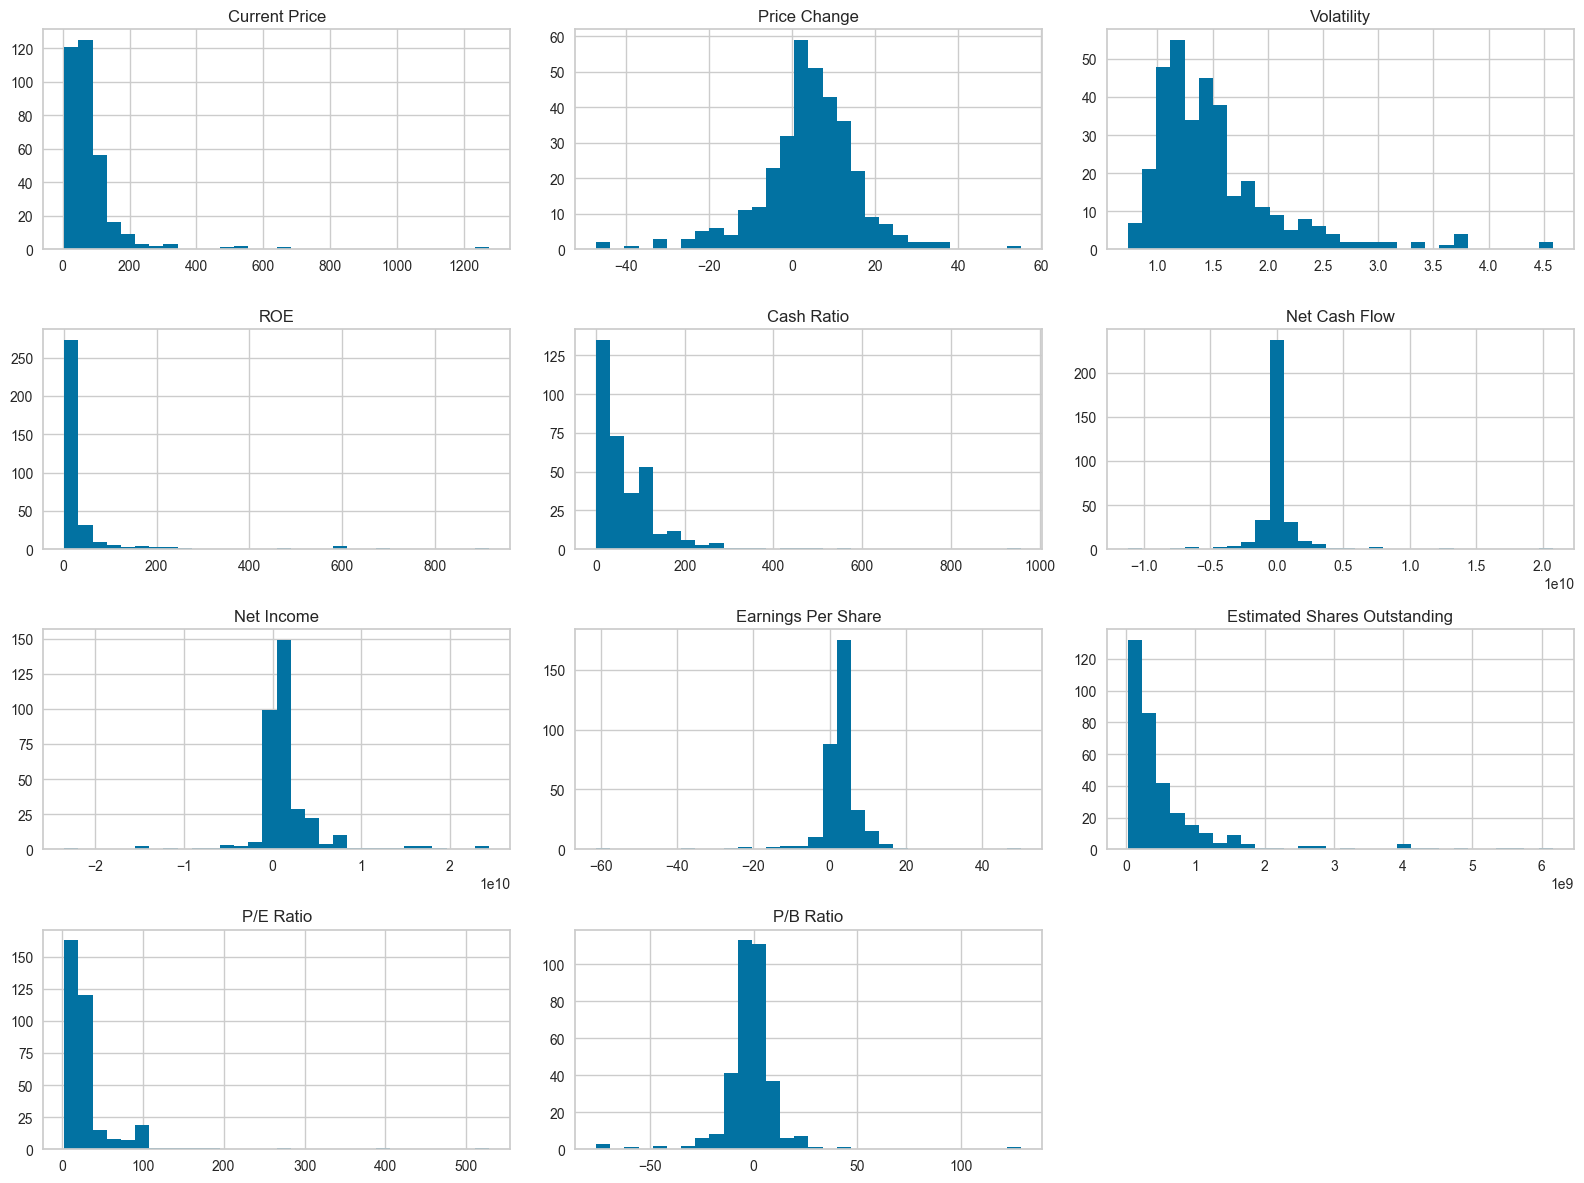

In [11]:
# Select numerical columns
numeric_cols = Trade_df.select_dtypes(include=np.number).columns

# Histograms
Trade_df[numeric_cols].hist(figsize=(16, 12), bins=30)
plt.tight_layout()
plt.show()

#### Observations

- Current Price is highly right-skewed, with most stocks priced below 200 and a small number of extreme values extending beyond 1,200.
- Price Change is approximately symmetric and centered around 0, with a slight right tail extending toward 40–60.
- Volatility is right-skewed, with most values concentrated between 1.0 and 2.0 and a few higher values extending beyond 3.5.
- ROE is heavily right-skewed, with most values clustered at lower levels and a small number of extreme values extending beyond 500.
- Cash Ratio is right-skewed, with most values below 100 and a long tail extending toward 1,000.
- Net Cash Flow is concentrated around 0, with a small number of extreme values on both the negative and positive sides.
- Net Income is concentrated around lower values, with a few extreme values on both the negative and positive sides.
- Earnings Per Share is concentrated around small positive values, with a long left tail extending toward -60.
- Estimated Shares Outstanding is right-skewed, with most values below 1e9 and a few large values extending beyond 4e9.
- P/E Ratio is right-skewed, with most values below 100 and a small number of extreme values extending toward 500.
- P/B Ratio is concentrated around 0 and is relatively symmetric around the center, with extreme values on both tails extending beyond -50 and 100.

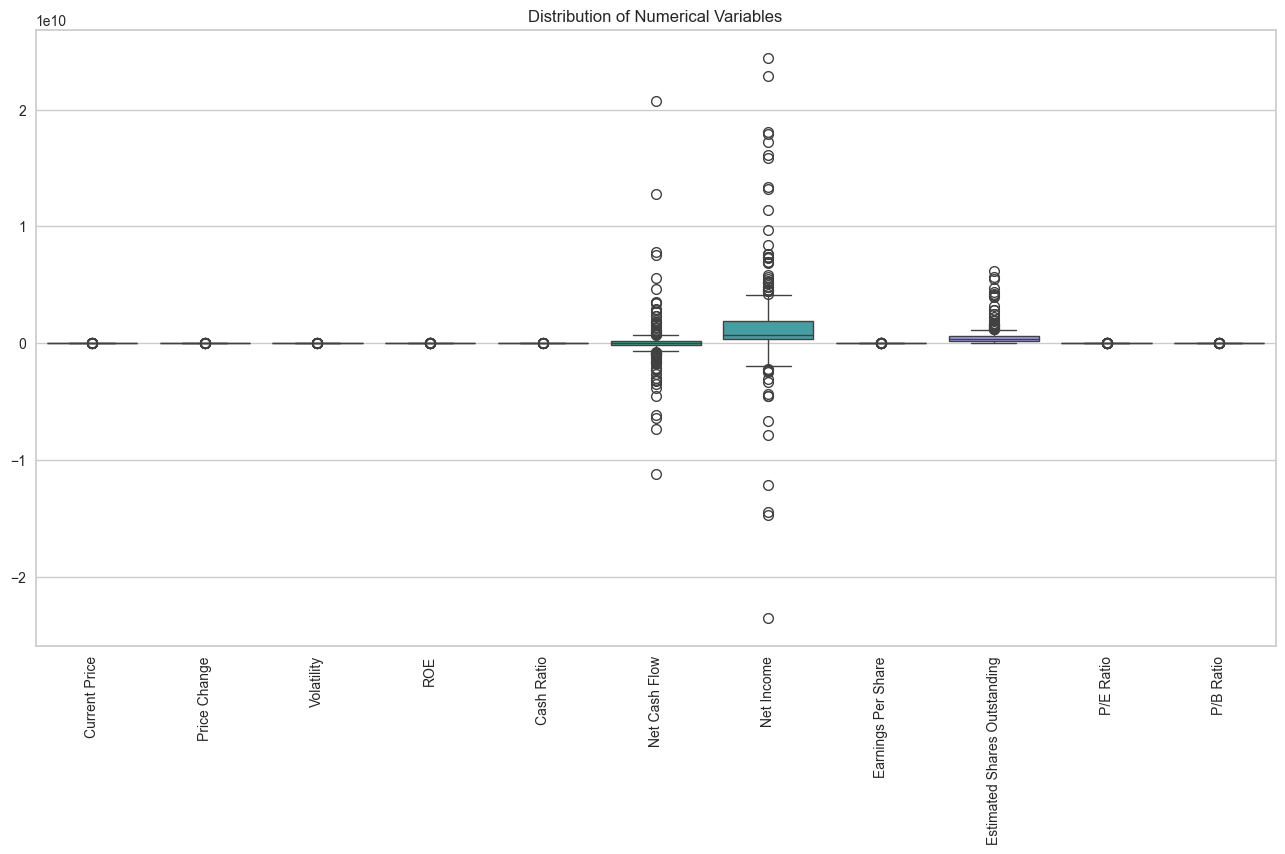

In [13]:
# Box Plot 
plt.figure(figsize=(16, 8))
sns.boxplot(data=Trade_df[numeric_cols])
plt.xticks(rotation=90)
plt.title("Distribution of Numerical Variables")
plt.show()

#### Observations

- The combined boxplot is dominated by Net Cash Flow, Net Income, and Estimated Shares Outstanding, which are on a much larger scale (around 1e10) than the remaining variables.
- Net Income shows the widest spread and the most extreme values, ranging from approximately -2.3e10 to 2.4e10.
- Net Cash Flow also shows a wide spread with extreme values on both the positive and negative sides, ranging from approximately -1.1e10 to 2.1e10.
- Estimated Shares Outstanding has a visible box with extreme values extending up to roughly 6e9, but appears compressed near 0 relative to Net Cash Flow and Net Income.
- Current Price, Price Change, Volatility, ROE, Cash Ratio, Earnings Per Share, P/E Ratio, and P/B Ratio appear compressed near 0 on this scale because their magnitudes are much smaller than the three dominant variables.
- The large difference in scale across variables makes it difficult to compare their distributions directly on a single shared axis.

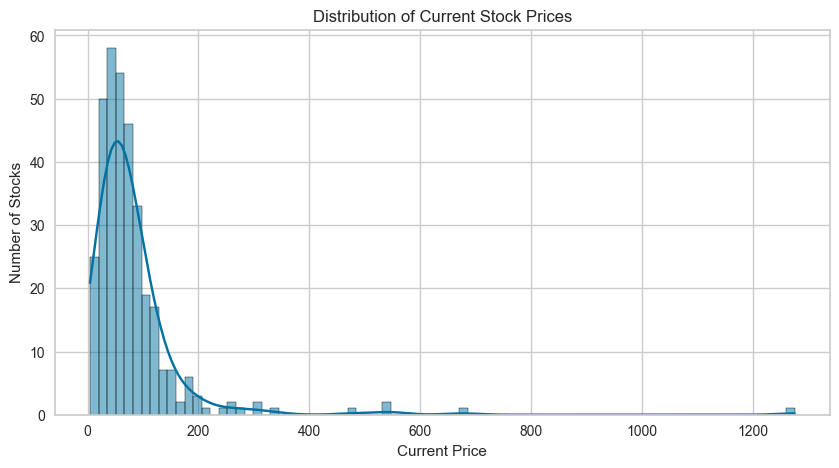

In [14]:
# Plot to show distribution of Current stock prices
plt.figure(figsize=(10, 5))
sns.histplot(Trade_df['Current Price'], kde=True)
plt.title('Distribution of Current Stock Prices')
plt.xlabel('Current Price')
plt.ylabel('Number of Stocks')
plt.show()

#### Observations

- The distribution of Current Price is strongly right-skewed.
- Most stocks are priced between 0 and 150, with the highest concentration around 50–75.
- The density curve shows a peak near 50–60, followed by a steady decline as price increases.
- A long thin tail extends from about 200 to over 1,200, representing a small number of high-priced stocks.
- A few isolated extreme values appear around 480, 550, 680, and 1,275.

### Bivariant Analysis

In [16]:
# Which economic sector has seen the maximum price increase on average?
sector_price_change = (
    Trade_df.groupby('GICS Sector')['Price Change']
    .mean()
    .sort_values(ascending=False)
)

sector_price_change

GICS Sector
Health Care                     9.585652
Consumer Staples                8.684750
Information Technology          7.217476
Telecommunications Services     6.956980
Real Estate                     6.205548
Consumer Discretionary          5.846093
Materials                       5.589738
Financials                      3.865406
Industrials                     2.833127
Utilities                       0.803657
Energy                        -10.228289
Name: Price Change, dtype: float64

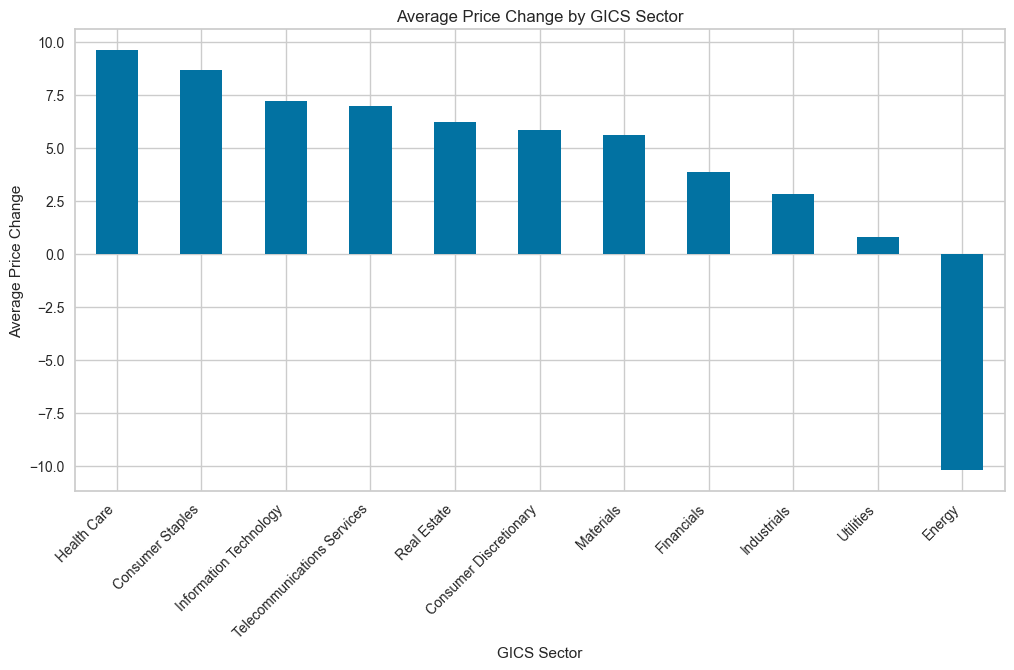

In [17]:
# Ploting the Economic sectors
plt.figure(figsize=(12, 6))
sector_price_change.plot(kind='bar')
plt.title('Average Price Change by GICS Sector')
plt.xlabel('GICS Sector')
plt.ylabel('Average Price Change')
plt.xticks(rotation=45, ha='right')
plt.show()

#### Observations

- Health Care has the highest average Price Change, followed closely by Consumer Staples.
- Information Technology, Telecommunications Services, Real Estate, Consumer Discretionary, and Materials show moderate positive average Price Changes, ranging from roughly 5.5 to 7.5.
- Financials and Industrials show smaller positive average Price Changes, below 4.
- Utilities shows a slightly positive average Price Change, close to 0.
- Energy is the only sector with a negative average Price Change, at approximately -10.
- Energy's average Price Change is roughly equal in magnitude but opposite in direction to Health Care's.

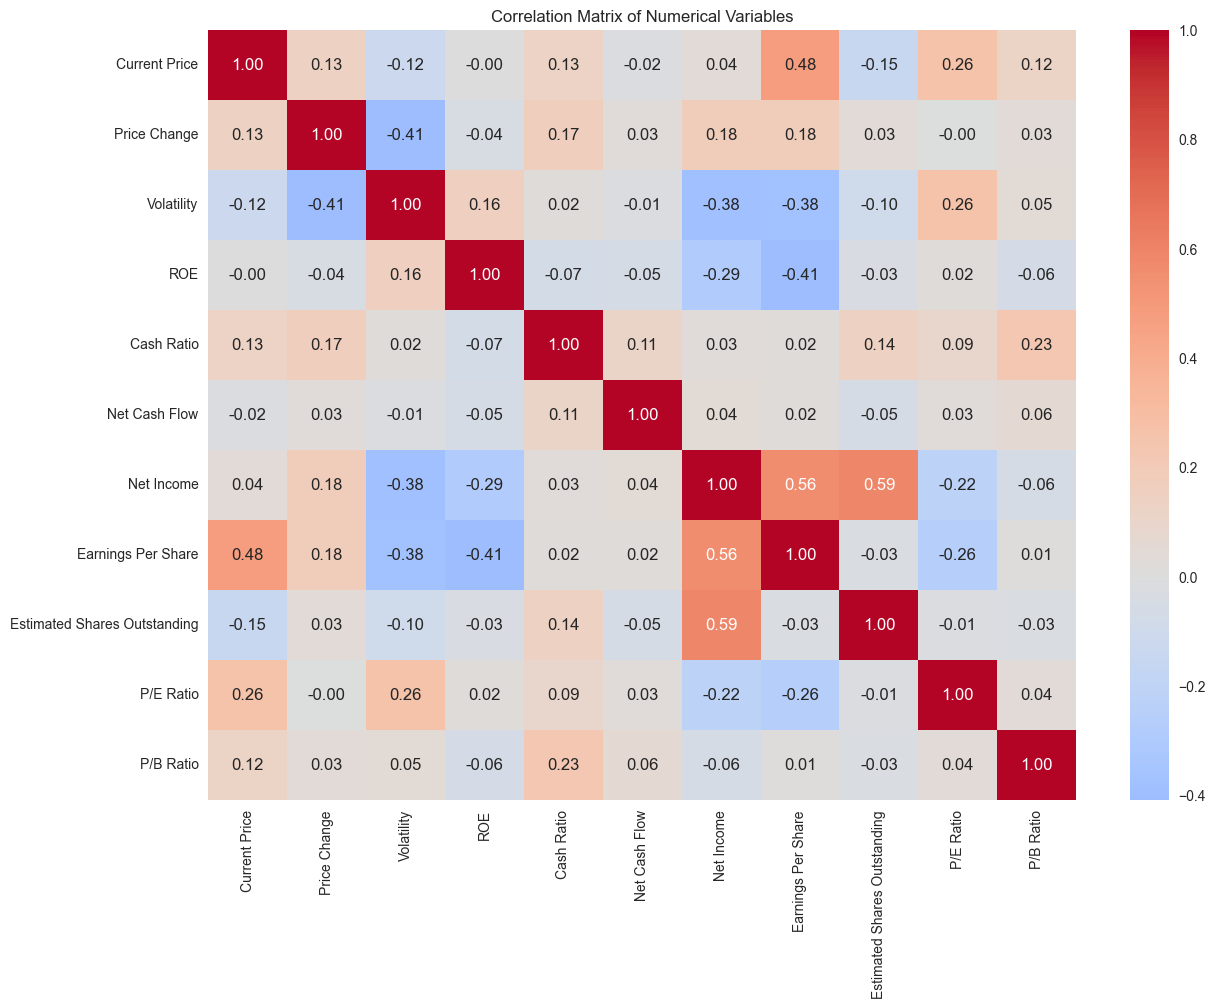

In [19]:
# How are the different variables correlated with each other?

plt.figure(figsize=(14, 10))

corr = Trade_df[numeric_cols].corr()

sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0
)

plt.title('Correlation Matrix of Numerical Variables')
plt.show()

#### Observations

- Current Price and Earnings Per Share show the strongest positive correlation among the variable pairs, at 0.48.
- Net Income shows moderate positive correlations with both Earnings Per Share (0.56) and Estimated Shares Outstanding (0.59).
- Earnings Per Share and ROE show a moderate negative correlation of -0.41.
- Volatility shows negative correlations with Price Change (-0.41), Net Income (-0.38), and Earnings Per Share (-0.38).
- ROE shows negative correlations with Net Income (-0.29) and Earnings Per Share (-0.41).
- P/E Ratio shows negative correlations with Net Income (-0.22) and Earnings Per Share (-0.26), and a positive correlation with Volatility (0.26).
- Most of the remaining variable pairs show weak correlations, generally ranging between -0.15 and 0.20.
- Net Cash Flow shows weak correlations with nearly all other variables, with none exceeding 0.11 in magnitude.

## Data Preprocessing

- Duplicate value check
- Missing value treatment
- Outlier check
- Feature engineering (if needed)
- Any other preprocessing steps (if needed)

## EDA

- It is a good idea to explore the data once again after manipulating it.

## K-means Clustering

## Hierarchical Clustering

## K-means vs Hierarchical Clustering

You compare several things, like:
- Which clustering technique took less time for execution?
- Which clustering technique gave you more distinct clusters, or are they the same?
- How many observations are there in the similar clusters of both algorithms?
- How many clusters are obtained as the appropriate number of clusters from both algorithms?

You can also mention any differences or similarities you obtained in the cluster profiles from both the clustering techniques.

## Actionable Insights and Recommendations

-